# Datasets

Combine real (dair-ai/emotion) and synthetic (ELSA) emotion datasets into a single dataframe with unified 'text', 'label', 'type' columns.

In [ ]:
import os
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split

In [ ]:
real_ds = load_dataset("dair-ai/emotion", "split")
# IF 'split' config produced an error:
# real_ds = load_dataset("dair-ai/emotion")

real_df = real_ds["train"].to_pandas()
real_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [ ]:
synth_ds = load_dataset("joyspace-ai/ELSA-Emotion-and-Language-Style-Alignment-Dataset")
synth_df = synth_ds["train"].to_pandas()
synth_df.head()

README.md:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

elsa_dataset.csv:   0%|          | 0.00/6.24M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10434 [00:00<?, ? examples/s]

,id,dair_ai_id,original_text,original_emotion,emotion_type,conversational,poetic,formal,narrative
0,1,1,i feel sorry about you because your point of v...,sadness,sadness,It's tough to see how your views have been sha...,"A heart heavy with sorrow, for your thoughts a...",It is regrettable that your perspective appear...,"I can't help but feel a deep sadness for you, ..."
1,2,1,i feel sorry about you because your point of v...,sadness,grief,I really feel for you; it’s a shame how those ...,"In the shadow of loss, I mourn the clarity of ...",It is disheartening to witness the impact of t...,"As I reflect on your situation, a wave of grie..."
2,3,1,i feel sorry about you because your point of v...,sadness,remorse,I wish things were different for you; it’s sad...,"With a heavy heart, I lament the influence of ...",There is a sense of regret regarding the educa...,"As I think about your beliefs, I feel a pang o..."
3,4,2,i feel like he s watching quietly because he s...,sadness,sadness,"It seems like he's just sitting there, accepti...","In silent observation, he sits, burdened by th...",He appears to be in a state of quiet observati...,"He watched from the shadows, a resigned figure..."
4,5,2,i feel like he s watching quietly because he s...,sadness,grief,"You can tell he's just there, quietly mourning...","He lingers in the stillness, grieving the ephe...",His demeanor suggests a profound sense of grie...,"In the quiet corners of his mind, he grieved, ..."


In [ ]:
print("dair-ai/emotion columns:", real_df.columns.tolist())
print("ELSA columns:", synth_df.columns.tolist())

dair-ai/emotion columns: ['text', 'label']
ELSA columns: ['id', 'dair_ai_id', 'original_text', 'original_emotion', 'emotion_type', 'conversational', 'poetic', 'formal', 'narrative']


## Add dataset type

In [ ]:
real_df["type"] = "real"
synth_df["type"] = "synthetic"

real_df.head()

,text,label,type
0,i didnt feel humiliated,0,real
1,i can go from feeling so hopeless to so damned...,0,real
2,im grabbing a minute to post i feel greedy wrong,3,real
3,i am ever feeling nostalgic about the fireplac...,2,real
4,i am feeling grouchy,3,real


In [ ]:
synth_df.head()

,id,dair_ai_id,original_text,original_emotion,emotion_type,conversational,poetic,formal,narrative,type
0,1,1,i feel sorry about you because your point of v...,sadness,sadness,It's tough to see how your views have been sha...,"A heart heavy with sorrow, for your thoughts a...",It is regrettable that your perspective appear...,"I can't help but feel a deep sadness for you, ...",synthetic
1,2,1,i feel sorry about you because your point of v...,sadness,grief,I really feel for you; it’s a shame how those ...,"In the shadow of loss, I mourn the clarity of ...",It is disheartening to witness the impact of t...,"As I reflect on your situation, a wave of grie...",synthetic
2,3,1,i feel sorry about you because your point of v...,sadness,remorse,I wish things were different for you; it’s sad...,"With a heavy heart, I lament the influence of ...",There is a sense of regret regarding the educa...,"As I think about your beliefs, I feel a pang o...",synthetic
3,4,2,i feel like he s watching quietly because he s...,sadness,sadness,"It seems like he's just sitting there, accepti...","In silent observation, he sits, burdened by th...",He appears to be in a state of quiet observati...,"He watched from the shadows, a resigned figure...",synthetic
4,5,2,i feel like he s watching quietly because he s...,sadness,grief,"You can tell he's just there, quietly mourning...","He lingers in the stillness, grieving the ephe...",His demeanor suggests a profound sense of grie...,"In the quiet corners of his mind, he grieved, ...",synthetic


## Transform datasets
ELSA:
Keep only conversational, original_emotion, and type. Rename conversational -> text, original_emotion -> label for further dataset combination.
We choose "conversational" because it mimics the real data the most.

dair-ai:
Map numeric labels to emotion names based on the information from dataset page.

In [ ]:
expected_elsa_cols = {"conversational", "original_emotion"}
missing = expected_elsa_cols - set(synth_df.columns)
if missing:
    raise ValueError(
        f"ELSA is missing expected column(s): {missing}. "
        f"Actual columns are: {synth_df.columns.tolist()}. "
        f"Update the column names above to match."
    )

synth_df = synth_df[["conversational", "original_emotion", "type"]].rename(
    columns={"conversational": "text", "original_emotion": "label"}
)

In [ ]:
synth_df

,text,label,type
0,It's tough to see how your views have been sha...,sadness,synthetic
1,I really feel for you; it’s a shame how those ...,sadness,synthetic
2,I wish things were different for you; it’s sad...,sadness,synthetic
3,"It seems like he's just sitting there, accepti...",sadness,synthetic
4,"You can tell he's just there, quietly mourning...",sadness,synthetic
...,...,...,...
10429,"I really enjoy their music, but it feels like ...",joy,synthetic
10430,"I totally love their music, but it feels like ...",joy,synthetic
10431,"I really admire their music, but I feel they h...",joy,synthetic
10432,"I’m so thankful for their music, but I feel li...",joy,synthetic


In [ ]:
label_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise",
}

real_df["label"] = real_df["label"].map(label_map)
real_df = real_df[["text", "label", "type"]]

real_df

,text,label,type
0,i didnt feel humiliated,sadness,real
1,i can go from feeling so hopeless to so damned...,sadness,real
2,im grabbing a minute to post i feel greedy wrong,anger,real
3,i am ever feeling nostalgic about the fireplac...,love,real
4,i am feeling grouchy,anger,real
...,...,...,...
15995,i just had a very brief time in the beanbag an...,sadness,real
15996,i am now turning and i feel pathetic that i am...,sadness,real
15997,i feel strong and good overall,joy,real
15998,i feel like this was such a rude comment and i...,anger,real


In [ ]:
print("Real label proportions:")
print(real_df["label"].value_counts(normalize=True))

print("\nSynthetic label counts (raw):")
print(synth_df["label"].value_counts(normalize=True))

Real label proportions:
label
joy         0.335125
sadness     0.291625
anger       0.134937
fear        0.121063
love        0.081500
surprise    0.035750
Name: proportion, dtype: float64

Synthetic label counts (raw):
label
joy         0.263082
anger       0.210753
sadness     0.158137
love        0.156987
fear        0.105616
surprise    0.105425
Name: proportion, dtype: float64


In [ ]:
real_train_pool, real_holdout = train_test_split(
    real_df,
    test_size=4000,
    random_state=42,
    shuffle=True,
    stratify=real_df["label"]
)

real_val, real_test = train_test_split(
    real_holdout,
    test_size=0.5,
    random_state=42,
    shuffle=True,
    stratify=real_holdout["label"]
)

real_train_pool = real_train_pool.reset_index(drop=True)
real_val = real_val.reset_index(drop=True)
real_test = real_test.reset_index(drop=True)

print("Real train pool:", len(real_train_pool))
print("Real validation:", len(real_val))
print("Real test:", len(real_test))

Real train pool: 12000
Real validation: 2000
Real test: 2000


In [ ]:
holdout_texts = set(real_val["text"]).union(set(real_test["text"]))

synth_df_clean = synth_df[
    ~synth_df["text"].isin(holdout_texts)
].reset_index(drop=True)

print("Synthetic before cleaning:", len(synth_df))
print("Synthetic after removing val/test duplicates:", len(synth_df_clean))
print("Removed:", len(synth_df) - len(synth_df_clean))

Synthetic before cleaning: 10434
Synthetic after removing val/test duplicates: 10434
Removed: 0


In [ ]:
ratios = [1.0, 0.75, 0.5, 0.25, 0.0]

In [ ]:
mixed_datasets = {}
TOTAL_TRAIN_SIZE = 10_000


for ratio in ratios:
    n_real = int(TOTAL_TRAIN_SIZE * ratio)
    n_synth = TOTAL_TRAIN_SIZE - n_real

    if n_real > 0:
        real_sample = real_train_pool.sample(
            n=n_real,
            random_state=42,
            replace=False
        )
    else:
        real_sample = pd.DataFrame(columns=real_train_pool.columns)

    if n_synth > 0:
        synth_sample = synth_df_clean.sample(
            n=n_synth,
            random_state=42,
            replace=False
        )
    else:
        synth_sample = pd.DataFrame(columns=synth_df_clean.columns)

    mixed_df = pd.concat([real_sample, synth_sample], ignore_index=True)

    # обязательно перемешиваем real и synthetic внутри train
    mixed_df = mixed_df.sample(frac=1, random_state=42).reset_index(drop=True)


    name = f"real_{int(ratio * 100)}_synth_{int((1-ratio) * 100)}"
    mixed_datasets[name] = mixed_df

    print("=" * 40)
    print(name)
    print("Size:", len(mixed_df))
    print("Source distribution:")
    print(mixed_df["type"].value_counts())
    print("Label distribution:")
    print(mixed_df["label"].value_counts())

real_100_synth_0
Size: 10000
Source distribution:
type
real    10000
Name: count, dtype: int64
Label distribution:
label
joy         3331
sadness     2902
anger       1378
fear        1212
love         823
surprise     354
Name: count, dtype: int64
real_75_synth_25
Size: 10000
Source distribution:
type
real         7500
synthetic    2500
Name: count, dtype: int64
Label distribution:
label
joy         3137
sadness     2582
anger       1544
fear        1223
love        1003
surprise     511
Name: count, dtype: int64
real_50_synth_50
Size: 10000
Source distribution:
type
synthetic    5000
real         5000
Name: count, dtype: int64
Label distribution:
label
joy         3030
sadness     2301
anger       1707
love        1154
fear        1133
surprise     675
Name: count, dtype: int64
real_25_synth_75
Size: 10000
Source distribution:
type
synthetic    7500
real         2500
Name: count, dtype: int64
Label distribution:
label
joy         2774
sadness     1985
anger       1917
love        135

In [ ]:
df_100_0 = mixed_datasets["real_100_synth_0"]
df_75_25 = mixed_datasets["real_75_synth_25"]
df_50_50 = mixed_datasets["real_50_synth_50"]
df_25_75 = mixed_datasets["real_25_synth_75"]
df_0_100 = mixed_datasets["real_0_synth_100"]

## Combine datasets

In [ ]:
combined_df = pd.concat([real_df, synth_df], ignore_index=True)
combined_df.sample(10)

,text,label,type
10985,i wanna talk tell you about sycf it stands for...,joy,real
5426,i feel so peaceful so i know i made the right ...,joy,real
2731,i feel joyful and not feeble,joy,real
10371,i was feeling a lot of self pride that i was s...,love,real
25585,It’s hilarious how they treat us like family; ...,joy,synthetic
2835,i feel so betrayed and humiliated,sadness,real
26235,I'm feeling really good about being ready for ...,joy,synthetic
11457,i feel so hopeless and strange and all i reall...,sadness,real
2433,i also feel more welcomed at lush than any oth...,joy,real
6346,i fared pretty well and was feeling quite plea...,joy,real


In [ ]:
print("Row counts by type:")
print(combined_df["type"].value_counts())

Row counts by type:
type
real         16000
synthetic    10434
Name: count, dtype: int64


In [ ]:
print("Row counts by type and label:")
print(combined_df.groupby(["type", "label"]).size())

Row counts by type and label:
type       label   
real       anger       2159
           fear        1937
           joy         5362
           love        1304
           sadness     4666
           surprise     572
synthetic  anger       2199
           fear        1102
           joy         2745
           love        1638
           sadness     1650
           surprise    1100
dtype: int64


In [ ]:
print(f"Total combined rows: {len(combined_df)}")

Total combined rows: 26434


Save the csv:

In [ ]:
combined_df.to_csv("combined_dataset.csv", index=False)
print("Saved to combined_dataset.csv")

Saved to combined_dataset.csv


# Mixing the dataset

In [ ]:
real_train_pool, real_test = train_test_split(
    real_df, test_size=0.2, stratify=real_df["label"], random_state=42
)

print("real_train_pool:", real_train_pool.shape)
print("real_test:", real_test.shape)

real_train_pool: (12800, 3)
real_test: (3200, 3)


In [ ]:
def build_mixed_dataset(real_df, synth_df, total_size, prop_real, random_state=42):
    """
    Build a training set of `total_size` rows at a given real:synthetic ratio,
    stratified by label so class balance stays constant across ratio conditions.
    """
    labels = real_df["label"].unique()
    n_real_total = int(total_size * prop_real)
    n_synth_total = total_size - n_real_total

    # target class distribution
    class_props = real_df["label"].value_counts(normalize=True)

    real_parts, synth_parts = [], []
    for label in labels:
        n_real_label = int(round(n_real_total * class_props[label]))
        n_synth_label = int(round(n_synth_total * class_props[label]))

        real_pool = real_df[real_df["label"] == label]
        synth_pool = synth_df[synth_df["label"] == label]

        # fixes asking for more rows than exist for that class
        n_real_label = min(n_real_label, len(real_pool))
        n_synth_label = min(n_synth_label, len(synth_pool))

        real_parts.append(real_pool.sample(n_real_label, random_state=random_state))
        synth_parts.append(synth_pool.sample(n_synth_label, random_state=random_state))

    mixed_df = pd.concat(real_parts + synth_parts, ignore_index=True)
    mixed_df = mixed_df.sample(frac=1, random_state=random_state).reset_index(drop=True)  # shuffle
    return mixed_df

In [ ]:
# Testing if it works
# It does
train_70_30 = build_mixed_dataset(real_train_pool, synth_df, total_size=5000, prop_real=0.7)

print(train_70_30["type"].value_counts())
print(train_70_30.groupby(["type", "label"]).size())

type
real         3500
synthetic    1500
Name: count, dtype: int64
type       label   
real       anger        472
           fear         424
           joy         1173
           love         285
           sadness     1021
           surprise     125
synthetic  anger        202
           fear         182
           joy          503
           love         122
           sadness      437
           surprise      54
dtype: int64


In [ ]:
TOTAL_SIZE = 10_000
ratios = [1.0, 0.75, 0.5, 0.25, 0.0]

mixed_datasets = {}

for ratio in ratios:
    n_real = int(TOTAL_SIZE * ratio)
    n_synth = TOTAL_SIZE - n_real

    real_sample = real_train_pool.sample(
        n=n_real,
        random_state=42,
        replace=False
    ) if n_real > 0 else pd.DataFrame(columns=real_train_pool.columns)

    synth_sample = synth_df.sample(
        n=n_synth,
        random_state=42,
        replace=False
    ) if n_synth > 0 else pd.DataFrame(columns=synth_df.columns)

    mixed_df = pd.concat([real_sample, synth_sample], ignore_index=True)

    # important: shuffle real and synthetic together
    mixed_df = mixed_df.sample(frac=1, random_state=42).reset_index(drop=True)

    name = f"real_{int(ratio * 100)}_synth_{int((1-ratio) * 100)}"
    mixed_datasets[name] = mixed_df

    print(name, mixed_df.shape)
    print(mixed_df["label"].value_counts())
    print()

real_100_synth_0 (10000, 3)
label
joy         3375
sadness     2922
anger       1338
fear        1194
love         806
surprise     365
Name: count, dtype: int64

real_75_synth_25 (10000, 3)
label
joy         3185
sadness     2593
anger       1519
fear        1192
love         997
surprise     514
Name: count, dtype: int64

real_50_synth_50 (10000, 3)
label
joy         3026
sadness     2283
anger       1702
love        1175
fear        1096
surprise     718
Name: count, dtype: int64

real_25_synth_75 (10000, 3)
label
joy         2797
sadness     1939
anger       1912
love        1367
fear        1084
surprise     901
Name: count, dtype: int64

real_0_synth_100 (10000, 3)
label
joy         2639
anger       2100
sadness     1590
love        1560
surprise    1056
fear        1055
Name: count, dtype: int64



In [ ]:
'''ratios = [1.0, 0.75, 0.5, 0.25, 0.0]  # proportion real: 100%, 75%, 50%, 25%, 0%
total_size = 10000  # because synthetic pool is 10,434 rows

datasets_by_ratio = {}
for prop_real in ratios:
    df = build_mixed_dataset(real_train_pool, synth_df, total_size=total_size, prop_real=prop_real)
    datasets_by_ratio[prop_real] = df
    print(f"prop_real={prop_real} -> {df['type'].value_counts().to_dict()}")
'''
# datasets do not have enough rows in the same proportions for every class, thats why why get
# prop_real=0.25 -> {'synthetic': 5901, 'real': 1999}
# prop_real=0.0 -> {'synthetic': 7317}
# even though total_size = 8000

'ratios = [1.0, 0.75, 0.5, 0.25, 0.0]  # proportion real: 100%, 75%, 50%, 25%, 0%\ntotal_size = 10000  # because synthetic pool is 10,434 rows\n\ndatasets_by_ratio = {}\nfor prop_real in ratios:\n    df = build_mixed_dataset(real_train_pool, synth_df, total_size=total_size, prop_real=prop_real)\n    datasets_by_ratio[prop_real] = df\n    print(f"prop_real={prop_real} -> {df[\'type\'].value_counts().to_dict()}")\n'

In [ ]:
# sanity check
#datasets_by_ratio[0.5].groupby("type").sample(5, random_state=42)

In [ ]:
'''os.makedirs("mixed_datasets", exist_ok=True)

for prop_real, df in datasets_by_ratio.items():
    filename = f"mixed_datasets/train_real{int(prop_real*100)}_synth{int((1-prop_real)*100)}.csv"
    df.to_csv(filename, index=False)
    print(f"Saved {filename} ({len(df)} rows)")

real_test.to_csv("mixed_datasets/real_test.csv", index=False)
print(f"Saved real_test.csv ({len(real_test)} rows)")'''

'os.makedirs("mixed_datasets", exist_ok=True)\n\nfor prop_real, df in datasets_by_ratio.items():\n    filename = f"mixed_datasets/train_real{int(prop_real*100)}_synth{int((1-prop_real)*100)}.csv"\n    df.to_csv(filename, index=False)\n    print(f"Saved {filename} ({len(df)} rows)")\n\nreal_test.to_csv("mixed_datasets/real_test.csv", index=False)\nprint(f"Saved real_test.csv ({len(real_test)} rows)")'

In [ ]:
# testing the reload
test_reload = pd.read_csv("real_50_synth_50.csv")
print(test_reload.shape)
test_reload.groupby("type").sample(3, random_state=1)

# Testing dataset compartability

In [ ]:
print("Real labels:", sorted(real_df["label"].unique()))
print("Synthetic labels:", sorted(synth_df["label"].unique()))

Real labels: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Synthetic labels: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


In [ ]:
for name, df in mixed_datasets.items():
    print(name, "nulls:", df.isnull().sum().sum(), "empty text:", (df["text"].str.strip() == "").sum())

real_100_synth_0 nulls: 0 empty text: 0
real_75_synth_25 nulls: 0 empty text: 0
real_50_synth_50 nulls: 0 empty text: 0
real_25_synth_75 nulls: 0 empty text: 0
real_0_synth_100 nulls: 0 empty text: 0


In [ ]:
# ELSA was built by taking sentences from dair-ai/emotion, so we need to check if there are any dublicates
for name, df in mixed_datasets.items():
    print(name, "duplicates:", df.duplicated(subset="text").sum())
    df = df.drop_duplicates(subset=["text"])
    print(name, "duplicates after cleaning:", df.duplicated(subset="text").sum())

real_100_synth_0 duplicates: 7
real_100_synth_0 duplicates after cleaning: 0
real_75_synth_25 duplicates: 4
real_75_synth_25 duplicates after cleaning: 0
real_50_synth_50 duplicates: 9
real_50_synth_50 duplicates after cleaning: 0
real_25_synth_75 duplicates: 14
real_25_synth_75 duplicates after cleaning: 0
real_0_synth_100 duplicates: 23
real_0_synth_100 duplicates after cleaning: 0


In [ ]:
for name, mixed_df in mixed_datasets.items():
    mixed_df.to_csv(f"{name}.csv", index=False)

In [ ]:
# Text length/style comparability
# ELSA's "conversational" may be a bit too long compared to the real texts. According to these reaults, however, they are not, so everything is fine.
combined_check = pd.concat([real_df.assign(source="real"), synth_df.assign(source="synthetic")])
combined_check["text_len"] = combined_check["text"].str.split().str.len()
combined_check.groupby("source")["text_len"].describe()

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
real,16000.0,19.166313,10.986905,2.0,11.0,17.0,25.0,66.0
synthetic,10434.0,18.956488,7.640942,4.0,13.0,18.0,23.0,69.0


## Text Preprocessing

In [ ]:
import re

def clean_text(text):
    text = str(text)
    text = text.strip()
    text = re.sub(r"\s+", " ", text)

    text = re.sub(r"http\S+|www\S+", " URL ", text)
    text = re.sub(r"@\w+", " USER ", text)

    return text

#Preparation

In [ ]:
df = df_0_100
df = df.dropna(subset=["text", "label"])
df = df[df["text"].str.len() > 2]

df = df.drop_duplicates(subset=["text"])
#check class balance
print(df["label"].value_counts())

label
joy         2635
anger       2092
sadness     1587
love        1560
fear        1052
surprise    1051
Name: count, dtype: int64


In [ ]:
# might be needed later depending on the model
label2id = {"sadness": 0, "joy": 1, "love": 2, "anger": 3, "fear": 4, "surprise": 5}
id2label = {v: k for k, v in label2id.items()}

In [ ]:
df["label_id"] = df["label"].map(label2id)

In [ ]:
real_df = df[df["type"] == 'real']
synthetic_df = df[df["type"] == 'synthetic']
#we put synthetic data only in train

In [ ]:

from sklearn.model_selection import train_test_split

train_df = pd.concat([real_df, synthetic_df], ignore_index=True)
val_df = real_val
test_df = real_test

In [ ]:
val_df["label_id"] = val_df["label"].map(label2id)
test_df["label_id"] = test_df["label"].map(label2id)

In [ ]:
val_df

,text,label,type,label_id
0,i worked thought that it was a good reason to ...,anger,real,3
1,i will not go into details from that long nigh...,joy,real,1
2,i feel like i have to redeem myself even thoug...,fear,real,4
3,im feeling somewhat verbally lame as i listen ...,sadness,real,0
4,i feel kinda popular,joy,real,1
...,...,...,...,...
1995,i have a feeling that id pick up some of the a...,joy,real,1
1996,i feel so much more productive at college and ...,joy,real,1
1997,i get it she feel betrayed and hurt,sadness,real,0
1998,i feel very privileged not only in being able ...,joy,real,1


In [ ]:
# results = {
#     "100_0": [0, 0, 0, 0, 0],
#     "75_25": [0, 0, 0, 0, 0],
#     "50_50": [0, 0, 0, 0, 0],
#     "25_75": [0, 0, 0, 0, 0],
#     "0_100": [0, 0, 0, 0, 0],
# }

## Model


In [ ]:
import pandas as pd
import numpy as np
import re
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [ ]:
train_df

,text,label,type,label_id
0,"It's always a thrill when I meet someone new, ...",joy,synthetic,1
1,It's like I'm sitting back and enjoying my own...,joy,synthetic,1
2,It's kind of funny how happy I am about the de...,joy,synthetic,1
3,I really appreciate how you feel about not sup...,joy,synthetic,1
4,"Wow, I didn’t expect to enjoy photography this...",surprise,synthetic,5
...,...,...,...,...
9972,"While I was feeling around, if I came across s...",surprise,synthetic,5
9973,"You know, it's hard not to feel uplifted think...",joy,synthetic,1
9974,"I guess I’ll show up today, even though I feel...",sadness,synthetic,0
9975,"I feel a bit silly, but I can't help but feel ...",anger,synthetic,3


In [ ]:
overlap = set(train_df["text"]).intersection(set(val_df["text"]))

print("Overlap before:", len(overlap))

train_df = train_df[~train_df["text"].isin(overlap)].reset_index(drop=True)

overlap_after = set(train_df["text"]).intersection(set(val_df["text"]))

print("Overlap after:", len(overlap_after))
print("New train size:", len(train_df))

Overlap before: 0
Overlap after: 0
New train size: 9977


In [ ]:
train_dataset = Dataset.from_pandas(train_df[["text", "label_id"]])
val_dataset = Dataset.from_pandas(val_df[["text", "label_id"]])
test_dataset = Dataset.from_pandas(test_df[["text", "label_id"]])

train_dataset = train_dataset.rename_column("label_id", "labels")
val_dataset = val_dataset.rename_column("label_id", "labels")
test_dataset = test_dataset.rename_column("label_id", "labels")

In [ ]:
model_name = "distilroberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    label2id=label2id,
    id2label=id2label
)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#tokenise

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)



Map:   0%|          | 0/9977 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./emotion_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none"
)

In [ ]:
def get_per_emotion_accuracy(trainer, test_dataset, ratio_name):
    import numpy as np
    import pandas as pd
    from sklearn.metrics import confusion_matrix

    labels = ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']

    predictions = trainer.predict(test_dataset)

    pred_labels = np.argmax(predictions.predictions, axis=-1)
    true_labels = predictions.label_ids

    cm = confusion_matrix(true_labels, pred_labels, labels=list(range(len(labels))))

    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    df = pd.DataFrame({
        "ratio": ratio_name,
        "emotion": labels,
        "accuracy": per_class_acc
    })

    return df

In [ ]:
trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )

trainer.train()
predictions = trainer.predict(test_dataset)
labels = ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

df_result = get_per_emotion_accuracy(
    trainer,
    test_dataset,
    ratio_name="100_0"
)

print(df_result)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.368964,0.272101,0.899000,0.867208,0.899326
2,0.229077,0.195011,0.926500,0.896840,0.926106
3,0.121125,0.190644,0.924500,0.893599,0.925082


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   ratio   emotion  accuracy
0  100_0     anger  0.945111
1  100_0      fear  0.943368
2  100_0       joy  0.791411
3  100_0      love  0.948148
4  100_0   sadness  0.913223
5  100_0  surprise  0.661972


In [ ]:
trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )

trainer.train()
predictions = trainer.predict(test_dataset)
labels = ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

df_result1 = get_per_emotion_accuracy(
    trainer,
    test_dataset,
    ratio_name="75_25"
)

print(df_result1)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.519904,0.320568,0.889500,0.847347,0.889109
2,0.307791,0.233050,0.916000,0.887994,0.916590
3,0.172542,0.227171,0.915000,0.886796,0.915554


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   ratio   emotion  accuracy
0  75_25     anger  0.943396
1  75_25      fear  0.912072
2  75_25       joy  0.828221
3  75_25      love  0.914815
4  75_25   sadness  0.892562
5  75_25  surprise  0.859155


In [ ]:
trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )

trainer.train()
predictions = trainer.predict(test_dataset)
labels = ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

df_result2 = get_per_emotion_accuracy(
    trainer,
    test_dataset,
    ratio_name="50_50"
)

print(df_result2)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.451300,0.397991,0.855000,0.814949,0.853974
2,0.300682,0.313608,0.892000,0.859660,0.892876
3,0.227591,0.288091,0.899000,0.864135,0.899304


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   ratio   emotion  accuracy
0  50_50     anger  0.915952
1  50_50      fear  0.898659
2  50_50       joy  0.809816
3  50_50      love  0.914815
4  50_50   sadness  0.880165
5  50_50  surprise  0.690141


In [ ]:
trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )

trainer.train()
predictions = trainer.predict(test_dataset)
labels = ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

df_result3 = get_per_emotion_accuracy(
    trainer,
    test_dataset,
    ratio_name="25_75"
)

print(df_result3)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.444875,0.545701,0.813500,0.762144,0.809846
2,0.374400,0.462976,0.851500,0.812645,0.851317
3,0.235706,0.410191,0.866000,0.823950,0.865600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   ratio   emotion  accuracy
0  25_75     anger  0.879931
1  25_75      fear  0.903130
2  25_75       joy  0.662577
3  25_75      love  0.844444
4  25_75   sadness  0.867769
5  25_75  surprise  0.676056


In [ ]:
trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )

trainer.train()
predictions = trainer.predict(test_dataset)
labels = ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

df_result4 = get_per_emotion_accuracy(
    trainer,
    test_dataset,
    ratio_name="0_100"
)

print(df_result4)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.310470,0.589886,0.816000,0.764034,0.813268
2,0.231087,0.654163,0.826000,0.784456,0.826727
3,0.128373,0.705344,0.824500,0.785905,0.824752


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   ratio   emotion  accuracy
0  0_100     anger  0.771870
1  0_100      fear  0.862891
2  0_100       joy  0.674847
3  0_100      love  0.885185
4  0_100   sadness  0.834711
5  0_100  surprise  0.563380


In [ ]:
all_emotion_results = pd.concat(
    [df_result, df_result1, df_result2, df_result3, df_result4],
    ignore_index=True
)

print(all_emotion_results)

    ratio   emotion  accuracy
0   100_0     anger  0.945111
1   100_0      fear  0.943368
2   100_0       joy  0.791411
3   100_0      love  0.948148
4   100_0   sadness  0.913223
5   100_0  surprise  0.661972
6   75_25     anger  0.943396
7   75_25      fear  0.912072
8   75_25       joy  0.828221
9   75_25      love  0.914815
10  75_25   sadness  0.892562
11  75_25  surprise  0.859155
12  50_50     anger  0.915952
13  50_50      fear  0.898659
14  50_50       joy  0.809816
15  50_50      love  0.914815
16  50_50   sadness  0.880165
17  50_50  surprise  0.690141
18  25_75     anger  0.879931
19  25_75      fear  0.903130
20  25_75       joy  0.662577
21  25_75      love  0.844444
22  25_75   sadness  0.867769
23  25_75  surprise  0.676056
24  0_100     anger  0.771870
25  0_100      fear  0.862891
26  0_100       joy  0.674847
27  0_100      love  0.885185
28  0_100   sadness  0.834711
29  0_100  surprise  0.563380


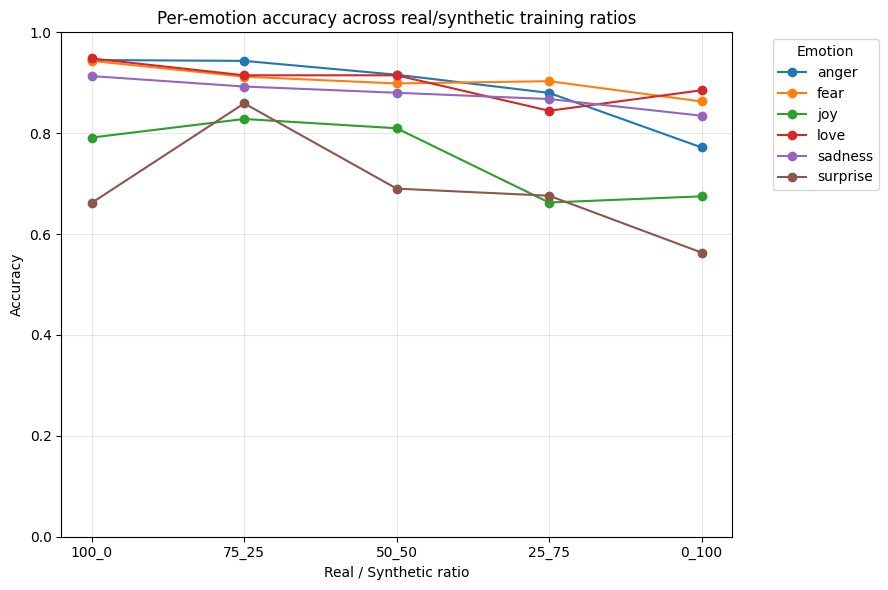

In [ ]:
plt.figure(figsize=(9, 6))

for emotion in emotion_order:
    sub = all_emotion_results[all_emotion_results["emotion"] == emotion]

    plt.plot(
        sub["ratio"].astype(str),
        sub["accuracy"],
        marker="o",
        linestyle="-",
        label=emotion
    )

plt.xlabel("Real / Synthetic ratio")
plt.ylabel("Accuracy")
plt.title("Per-emotion accuracy across real/synthetic training ratios")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(title="Emotion", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
'''for i in range(5):
    print(i)
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )

    trainer.train()
    predictions = trainer.predict(test_dataset)
    labels = ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
    pred_labels = np.argmax(predictions.predictions, axis=-1)
    true_labels = predictions.label_ids

    print(classification_report(
        true_labels,
        pred_labels,
        target_names=labels
    ))
    accuracy = accuracy_score(true_labels, pred_labels)
    results["0_100"][i] = accuracy'''

0


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.456940,1.105031,0.613000,0.579465,0.625367
2,0.337778,1.273656,0.596500,0.572681,0.612728
3,0.212686,1.416760,0.588000,0.560958,0.602826


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.024238,3.067350,0.591000,0.559971,0.606495
2,0.097443,3.402804,0.548000,0.541769,0.557968
3,0.072362,2.807496,0.607500,0.583391,0.620460


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

       anger       0.77      0.52      0.62       583
        fear       0.87      0.55      0.67       671
         joy       0.34      0.79      0.47       163
        love       0.43      0.76      0.55       270
     sadness       0.65      0.64      0.65       242
    surprise       0.45      0.45      0.45        71

    accuracy                           0.60      2000
   macro avg       0.58      0.62      0.57      2000
weighted avg       0.69      0.60      0.61      2000



In [ ]:
results

{'100_0': [0.9225, 0.9285, 0.924, 0.9225, 0.9205],
 '75_25': [0.927, 0.9195, 0.9165, 0.918, 0.9165],
 '50_50': [0.8895, 0.905, 0.8985, 0.9005, 0.9035],
 '25_75': [0.8485, 0.86, 0.871, 0.873, 0.864],
 '0_100': [0.5965, 0.621, 0.5885, 0.5935, 0.598]}

In [ ]:
results = {
 '100_0': [0.9225, 0.9285, 0.924, 0.9225, 0.9205],
 '75_25': [0.927, 0.9195, 0.9165, 0.918, 0.9165],
 '50_50': [0.8895, 0.905, 0.8985, 0.9005, 0.9035],
 '25_75': [0.8485, 0.86, 0.871, 0.873, 0.864],
 '0_100': [0.5965, 0.621, 0.5885, 0.5935, 0.598]}

##Graphs

In [ ]:
import numpy as np
import pandas as pd

summary = []

for ratio, scores in results.items():
    summary.append({
        "ratio": ratio,
        "mean_accuracy": np.mean(scores),
        "std_accuracy": np.std(scores, ddof=1)
    })

summary_df = pd.DataFrame(summary)

print(summary_df)

   ratio  mean_accuracy  std_accuracy
0  100_0         0.9236      0.003008
1  75_25         0.9195      0.004373
2  50_50         0.8994      0.006087
3  25_75         0.8633      0.009795
4  0_100         0.5995      0.012555


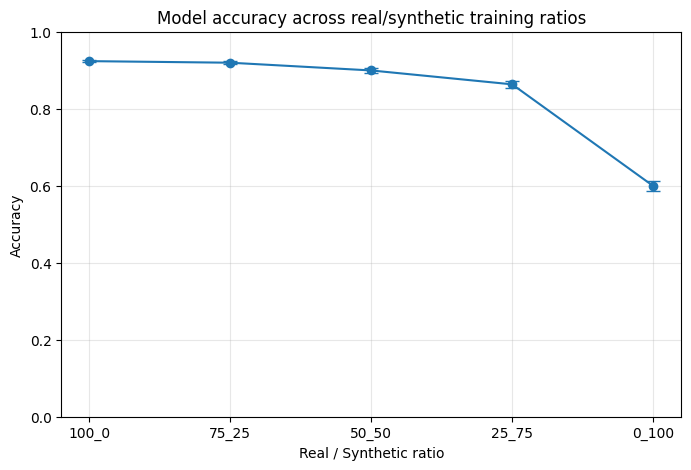

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.errorbar(
    summary_df["ratio"],
    summary_df["mean_accuracy"],
    yerr=summary_df["std_accuracy"],
    fmt="o-",
    capsize=5
)

plt.xlabel("Real / Synthetic ratio")
plt.ylabel("Accuracy")
plt.title("Model accuracy across real/synthetic training ratios")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

plt.show()